In [1]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-geometric -f https://data.pyg.org/whl/torch-{torch_version}.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [1]:
import torch
import random
import community.community_louvain as community_louvain
import sys
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import torch_geometric
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json
from torch_geometric.utils import to_dense_adj
from torch_geometric.nn import Node2Vec, GCNConv, GATConv
from sklearn.cluster import KMeans
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
from IPython.display import HTML
from torch_geometric.data import Data
from networkx.algorithms import community


%matplotlib inline

# Configuración de la semilla para reproducibilidad
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


# **IMPORTACIÓN Y VISUALIZACIÓN DE LA DATA**

In [3]:
dataset = Amazon(root='data/Amazon', name='Computers')

data = dataset[0]
print(f'Dataset: {dataset}:')
print('======================')
print(f'Número de nodos: {data.num_nodes}')
print(f'Número de aristas: {data.num_edges}')
print(f'Número de clases: {dataset.num_classes}')
print(f'Dimensión de características: {dataset.num_features}')
print("\n")
data

Dataset: AmazonComputers():
Número de nodos: 13752
Número de aristas: 491722
Número de clases: 10
Dimensión de características: 767




Data(x=[13752, 767], edge_index=[2, 491722], y=[13752])

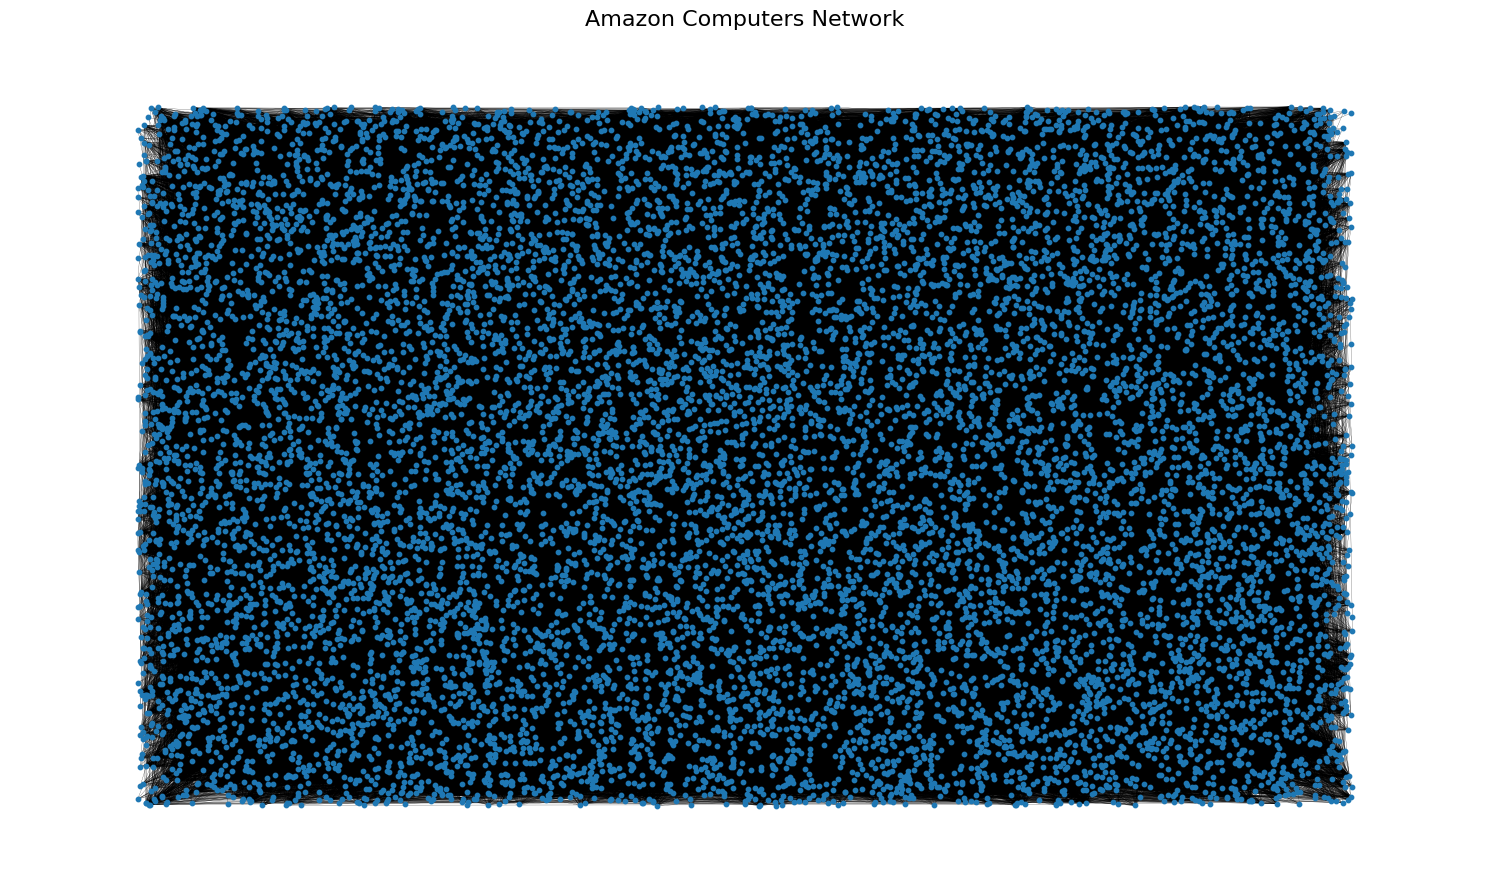

In [4]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}

nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)
plt.title("Amazon Computers Network", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
nodes_data = []
for node_id in range(min(5000, data.num_nodes)):
    if node_id < len(data.y):
        group = int(data.y[node_id].item())
    else:
        group = 0

    nodes_data.append({
        "id": str(node_id),
        "group": group
    })

edges_data = []
for edge in edge_index_list.values:
    source, target = edge
    if source < 5000 and target < 5000:
        edges_data.append({
            "source": str(source),
            "target": str(target)
        })

graph_data = {
    "nodes": nodes_data,
    "links": edges_data
}

graph_json = json.dumps(graph_data)

html_code = f"""
<!DOCTYPE html>
<html>
<head>
    <style> body {{ margin: 0; }} </style>
    <script src="https://unpkg.com/3d-force-graph@1.70.5/dist/3d-force-graph.min.js"></script>
</head>
<body>
    <div id="3d-graph" style="width: 100%; height: 600px;"></div>

    <script>
        // Parse the data
        const graphData = {graph_json};

        // Node colors based on group
        const colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'];

        // Initialize the 3D force graph
        const Graph = ForceGraph3D()
            (document.getElementById('3d-graph'))
            .graphData(graphData)
            .nodeColor(node => colors[node.group % colors.length])
            .nodeRelSize(3)
            .linkWidth(0.2)
            .linkOpacity(0.5)
            .backgroundColor('#FFFFFF')
            .nodeLabel(node => `Node ${{node.id}}`)
            .linkDirectionalParticles(1)
            .linkDirectionalParticleWidth(0.5)
            .enableNodeDrag(true)
            .enableNavigationControls(true)
            .showNavInfo(true);

        // Handle window resize
        window.addEventListener('resize', () => {{
            Graph.width(document.getElementById('3d-graph').clientWidth)
                .height(document.getElementById('3d-graph').clientHeight);
        }});

        // Instructions
        console.log("Navigation controls: Left-click + drag to rotate, right-click + drag to pan, scroll to zoom");
    </script>
</body>
</html>
"""

HTML(html_code)

# **ANALISIS EXPLORATORIO**

PROPIEDADES TOPOLÓGICAS BÁSICAS

In [13]:
G = to_networkx(data, to_undirected=True)

print("\n== PROPIEDADES TOPOLÓGICAS BÁSICAS ==")
print(f"Total de nodos: {G.number_of_nodes()}")
print(f"Total de aristas: {G.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G):.8f}")
print(f"¿Es conexo? {nx.is_connected(G)}")

num_components = nx.number_connected_components(G)
print(f"Número de componentes conexas: {num_components}")

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
print(f"Tamaño de las componentes: {component_sizes}")

avg_degree = np.mean([d for _, d in G.degree()])
print(f"Grado promedio: {avg_degree:.4f}")


== PROPIEDADES TOPOLÓGICAS BÁSICAS ==
Total de nodos: 13752
Total de aristas: 245861
Densidad del grafo: 0.00260028
¿Es conexo? False
Número de componentes conexas: 314
Tamaño de las componentes: [13381, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 7, 1, 2, 1, 1, 1, 3, 1, 1, 3, 1, 2, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

ANÁLISIS DE CAMINOS


In [5]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Tamaño de la componente gigante: {len(largest_cc)} nodos")

print("Calculando una aproximación mediante muestreo...")

sampled_nodes = np.random.choice(list(G_lcc.nodes()), min(1300, len(G_lcc)), replace=False)
max_path = 0
for node in sampled_nodes:
    paths = nx.single_source_shortest_path_length(G_lcc, node)
    if max(paths.values()) > max_path:
        max_path = max(paths.values())
print(f"Diámetro aproximado (muestreado): {max_path}")


print("Calculando longitud media de caminos mediante muestreo...")

sampled_nodes = np.random.choice(list(G_lcc.nodes()), min(1300, len(G_lcc)), replace=False)
path_lengths = []
for node in sampled_nodes:
    paths = nx.single_source_shortest_path_length(G_lcc, node)
    path_lengths.extend(list(paths.values()))
avg_path_length = np.mean(path_lengths)
print(f"Longitud media de caminos más cortos (muestreada): {avg_path_length:.4f}")


Tamaño de la componente gigante: 13381 nodos
Calculando una aproximación mediante muestreo...
Diámetro aproximado (muestreado): 10
Calculando longitud media de caminos mediante muestreo...
Longitud media de caminos más cortos (muestreada): 3.3898


MEDIDAS DE CENTRALIDAD

In [6]:
if G.number_of_nodes() > 5000:
    print("Grafo grande detectado, usando una muestra de nodos para cálculos de centralidad...")
    sample_size = min(1000, len(largest_cc))
    sampled_nodes = list(np.random.choice(list(largest_cc), sample_size, replace=False))
    G_sample = G.subgraph(sampled_nodes).copy()
    print(f"Muestra de {len(G_sample)} nodos seleccionada.")
else:
    G_sample = G_lcc

print("Calculando centralidad de grado...")
degree_centrality = nx.degree_centrality(G_sample)
print("Top 10 nodos con mayor centralidad de grado:")
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_degree:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de intermediación (betweenness)...")
if len(G_sample) > 500:
    print("  Usando una muestra más pequeña para betweenness...")
    betweenness_sample = list(np.random.choice(list(G_sample.nodes()), min(500, len(G_sample)), replace=False))
    G_small_sample = G_sample.subgraph(betweenness_sample).copy()
    betweenness_centrality = nx.betweenness_centrality(G_small_sample, k=min(100, len(G_small_sample)))
else:
    betweenness_centrality = nx.betweenness_centrality(G_sample)

print("Top 10 nodos con mayor centralidad de intermediación:")
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_betweenness:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de cercanía (closeness)...")
if len(G_sample) > 500:
    closeness_centrality = nx.closeness_centrality(G_small_sample)
else:
    closeness_centrality = nx.closeness_centrality(G_sample)

print("Top 10 nodos con mayor centralidad de cercanía:")
sorted_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_closeness:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de vector propio (eigenvector)...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(G_sample, max_iter=100)
    print("Top 10 nodos con mayor centralidad de vector propio:")
    sorted_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    for node, centrality in sorted_eigenvector:
        print(f"  Nodo {node}: {centrality:.6f}")
except:
    print("  El cálculo de eigenvector centrality no convergió. Intentando con power iteration...")
    try:
        eigenvector_centrality = nx.eigenvector_centrality_numpy(G_sample)
        print("Top 10 nodos con mayor centralidad de vector propio:")
        sorted_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
        for node, centrality in sorted_eigenvector:
            print(f"  Nodo {node}: {centrality:.6f}")
    except:
        print("  No se pudo calcular la centralidad de vector propio.")


Grafo grande detectado, usando una muestra de nodos para cálculos de centralidad...
Muestra de 1000 nodos seleccionada.
Calculando centralidad de grado...
Top 10 nodos con mayor centralidad de grado:
  Nodo 8140: 0.187187
  Nodo 1524: 0.113113
  Nodo 2300: 0.057057
  Nodo 590: 0.049049
  Nodo 12980: 0.041041
  Nodo 995: 0.037037
  Nodo 7920: 0.037037
  Nodo 6704: 0.030030
  Nodo 6928: 0.028028
  Nodo 6551: 0.026026

Calculando centralidad de intermediación (betweenness)...
  Usando una muestra más pequeña para betweenness...
Top 10 nodos con mayor centralidad de intermediación:
  Nodo 7920: 0.044051
  Nodo 590: 0.036459
  Nodo 2300: 0.036045
  Nodo 5816: 0.035839
  Nodo 9051: 0.034225
  Nodo 1917: 0.022475
  Nodo 2151: 0.018685
  Nodo 9306: 0.017344
  Nodo 4203: 0.013682
  Nodo 2853: 0.010190

Calculando centralidad de cercanía (closeness)...
Top 10 nodos con mayor centralidad de cercanía:
  Nodo 590: 0.107020
  Nodo 7920: 0.104588
  Nodo 7172: 0.100771
  Nodo 2300: 0.095706
  Nodo 462

DISTRIBUCIÓN DE GRADOS

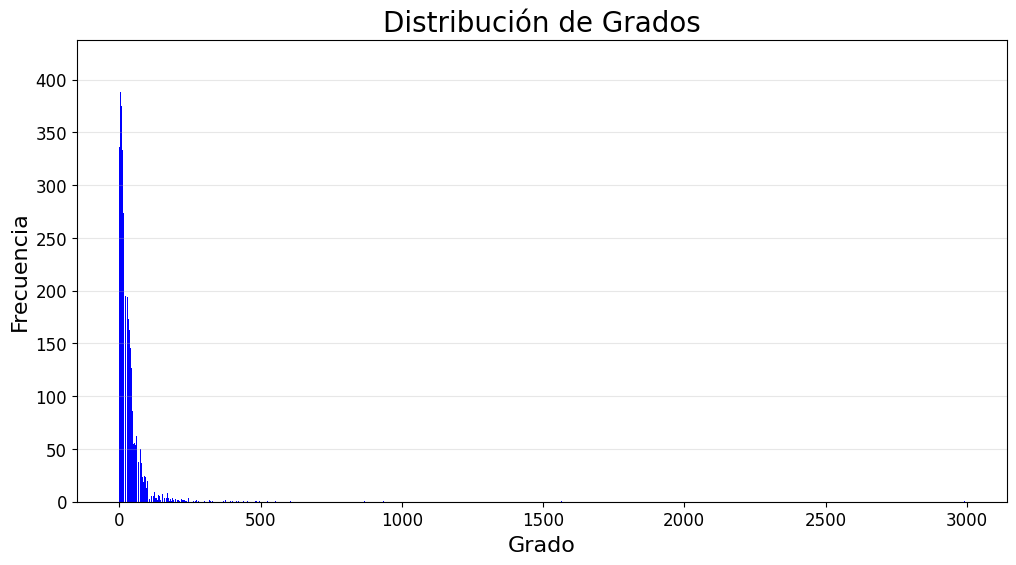

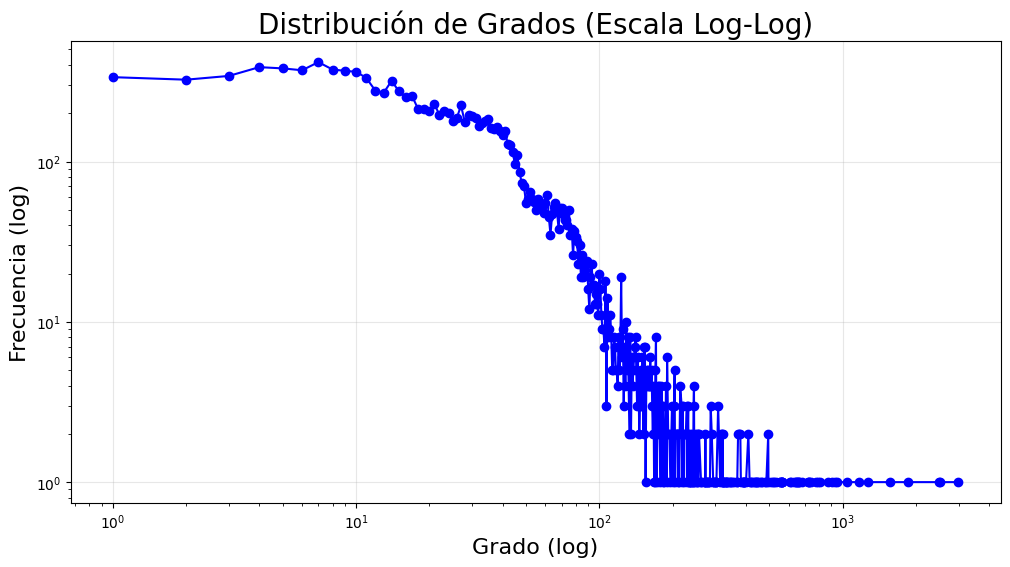

In [7]:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degree_values = np.arange(len(degree_count))

plt.figure(figsize=(12, 6))
plt.bar(degree_values, degree_count, width=0.80, color="b")
plt.title("Distribución de Grados", fontsize=20)
plt.ylabel("Frecuencia", fontsize=16)
plt.xlabel("Grado", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.loglog(degree_values[degree_count > 0], degree_count[degree_count > 0], 'bo-')
plt.title("Distribución de Grados (Escala Log-Log)", fontsize=20)
plt.ylabel("Frecuencia (log)", fontsize=16)
plt.xlabel("Grado (log)", fontsize=16)
plt.grid(alpha=0.3)
plt.show()


COEFICIENTE DE CLUSTERING Y TRANSITIVIDAD


== CLUSTERING Y TRANSITIVIDAD ==
Calculando coeficiente de clustering global...
Transitividad global (fracción de triángulos): 0.107739
Calculando coeficiente de clustering promedio...
Coeficiente de clustering promedio: 0.351305
Calculando distribución de coeficientes de clustering...


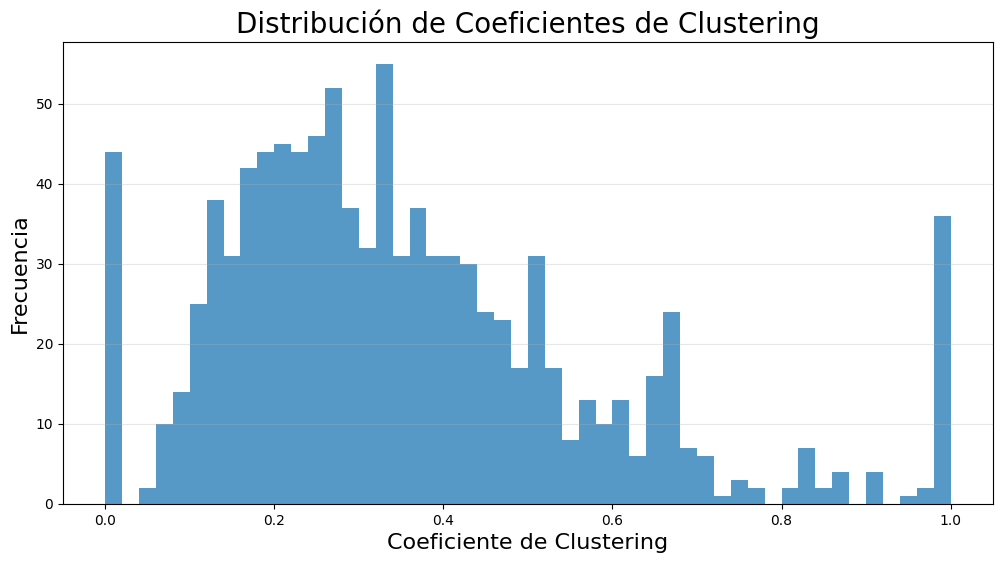

In [8]:

print("\n== CLUSTERING Y TRANSITIVIDAD ==")
print("Calculando coeficiente de clustering global...")
transitivity = nx.transitivity(G)
print(f"Transitividad global (fracción de triángulos): {transitivity:.6f}")

print("Calculando coeficiente de clustering promedio...")
avg_clustering = nx.average_clustering(G)
print(f"Coeficiente de clustering promedio: {avg_clustering:.6f}")

print("Calculando distribución de coeficientes de clustering...")
if G.number_of_nodes() > 5000:
    sample_nodes = np.random.choice(list(G.nodes()), min(1000, G.number_of_nodes()), replace=False)
    clustering_coeffs = nx.clustering(G, nodes=sample_nodes)
else:
    clustering_coeffs = nx.clustering(G)

plt.figure(figsize=(12, 6))
plt.hist(list(clustering_coeffs.values()), bins=50, alpha=0.75)
plt.title("Distribución de Coeficientes de Clustering", fontsize=20)
plt.xlabel("Coeficiente de Clustering", fontsize=16)
plt.ylabel("Frecuencia", fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

DETECCIÓN DE COMUNIDADES

Usando muestra de 1000 nodos para detección de comunidades
Detectando comunidades con el algoritmo de Louvain...
Número de comunidades detectadas: 297
Tamaño promedio de comunidad: 3.37 nodos
Tamaño mínimo de comunidad: 1 nodos
Tamaño máximo de comunidad: 135 nodos


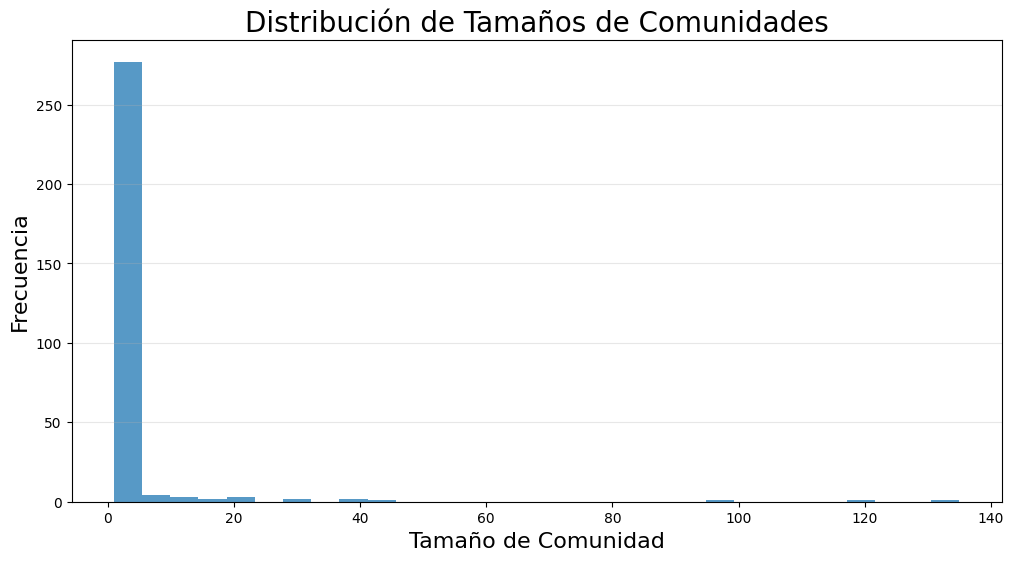

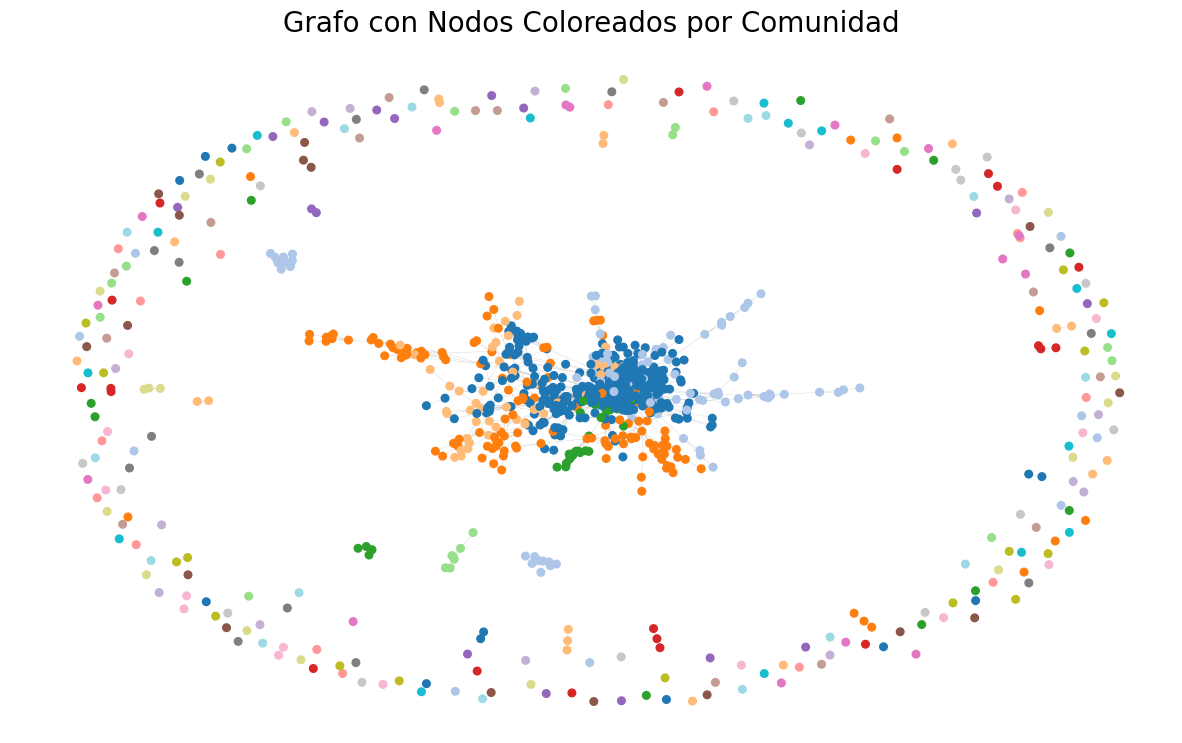

In [9]:
if G.number_of_nodes() > 1000:
    community_graph = G_sample
    print(f"Usando muestra de {community_graph.number_of_nodes()} nodos para detección de comunidades")
else:
    community_graph = G
    print(f"Usando grafo completo ({community_graph.number_of_nodes()} nodos) para detección de comunidades")

try:
    print("Detectando comunidades con el algoritmo de Louvain...")
    partition = community_louvain.best_partition(community_graph)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)

    print(f"Número de comunidades detectadas: {len(communities)}")
    community_sizes = [len(nodes) for comm_id, nodes in communities.items()]
    print(f"Tamaño promedio de comunidad: {np.mean(community_sizes):.2f} nodos")
    print(f"Tamaño mínimo de comunidad: {min(community_sizes)} nodos")
    print(f"Tamaño máximo de comunidad: {max(community_sizes)} nodos")

    plt.figure(figsize=(12, 6))
    plt.hist(community_sizes, bins=30, alpha=0.75)
    plt.title("Distribución de Tamaños de Comunidades", fontsize=20)
    plt.xlabel("Tamaño de Comunidad", fontsize=16)
    plt.ylabel("Frecuencia", fontsize=16)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    if community_graph.number_of_nodes() <= 1000:
        plt.figure(figsize=(15, 9))
        colors = [partition[node] for node in community_graph.nodes()]
        nx.draw_networkx(
            community_graph,
            pos=nx.spring_layout(community_graph, seed=42),
            node_color=colors,
            node_size=30,
            with_labels=False,
            edge_color='gray',
            width=0.1,
            cmap=plt.cm.tab20
        )
        plt.title("Grafo con Nodos Coloreados por Comunidad", fontsize=20)
        plt.axis('off')
        plt.savefig('community_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
except ImportError:
    print("La librería 'community' no está instalada. Instalála con: pip install python-louvain")
    print("Usando algoritmo alternativo para detección de comunidades...")

    try:
        communities = community.greedy_modularity_communities(community_graph)
        print(f"Número de comunidades detectadas: {len(communities)}")
        community_sizes = [len(comm) for comm in communities]
        print(f"Tamaño promedio de comunidad: {np.mean(community_sizes):.2f} nodos")
        print(f"Tamaño mínimo de comunidad: {min(community_sizes)} nodos")
        print(f"Tamaño máximo de comunidad: {max(community_sizes)} nodos")
    except:
        print("No se pudo realizar la detección de comunidades.")

ANÁLISIS DE ASORTATIVIDAD

In [10]:
print("Calculando coeficiente de asortatividad por grado...")
try:
    assortativity = nx.degree_assortativity_coefficient(G)
    print(f"Coeficiente de asortatividad: {assortativity:.6f}")

    if assortativity > 0.1:
        print("  El grafo es asortativo: nodos con grado similar tienden a conectarse entre sí.")
    elif assortativity < -0.1:
        print("  El grafo es disasortativo: nodos con grado diferente tienden a conectarse entre sí.")
    else:
        print("  El grafo no muestra un patrón claro de asortatividad.")
except:
    print("No se pudo calcular el coeficiente de asortatividad.")

Calculando coeficiente de asortatividad por grado...
Coeficiente de asortatividad: -0.056488
  El grafo no muestra un patrón claro de asortatividad.


IDENTIFICACIÓN DE BRIDGES (PUENTES)

Nodos con grado <= 4: 1390 de 13471 (10.32%)
Subgrafo filtrado: 1390 nodos y 258 aristas
Muestra del subgrafo filtrado: 1000 nodos y 126 aristas
El subgrafo filtrado tiene 888 componentes conexas
Tamaño de las 5 componentes más grandes: [6, 5, 4, 3, 3]
Buscando puentes en el grafo filtrado...
Número de puentes encontrados: 91
Ejemplo de puentes: [(6162, 12311), (4132, 3025), (4140, 7765), (6193, 4864), (10306, 1409)]
Número de nodos que forman parte de puentes: 172
Porcentaje de nodos del subgrafo: 17.20%
Distribución de grados de nodos en puentes:
  Grado 1: 46 nodos (26.74%)
  Grado 2: 36 nodos (20.93%)
  Grado 3: 41 nodos (23.84%)
  Grado 4: 49 nodos (28.49%)


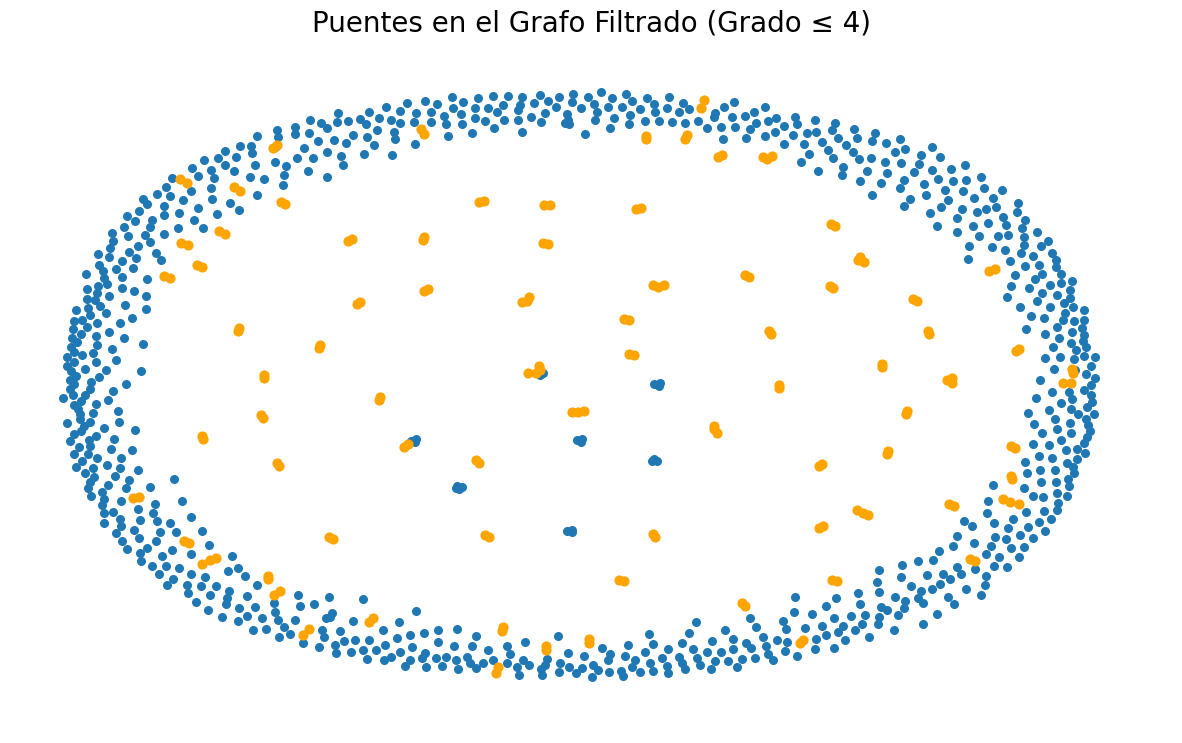

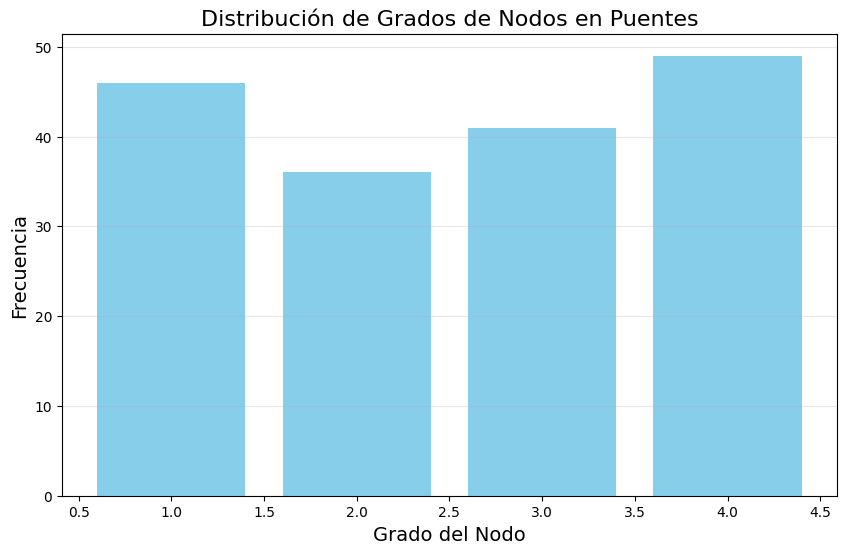

In [11]:
node_degrees = dict(G.degree())

max_degree_threshold = 4

low_degree_nodes = [node for node, degree in node_degrees.items() if degree <= max_degree_threshold]
print(f"Nodos con grado <= {max_degree_threshold}: {len(low_degree_nodes)} de {G.number_of_nodes()} ({len(low_degree_nodes)/G.number_of_nodes()*100:.2f}%)")

G_filtered = G.subgraph(low_degree_nodes)
print(f"Subgrafo filtrado: {G_filtered.number_of_nodes()} nodos y {G_filtered.number_of_edges()} aristas")

if G_filtered.number_of_nodes() > 1000:
    sample_size = 1000
    filtered_nodes_sample = list(G_filtered.nodes())
    random.shuffle(filtered_nodes_sample)
    filtered_nodes_sample = filtered_nodes_sample[:sample_size]
    G_bridge_sample = G.subgraph(filtered_nodes_sample)
    print(f"Muestra del subgrafo filtrado: {G_bridge_sample.number_of_nodes()} nodos y {G_bridge_sample.number_of_edges()} aristas")
    bridge_graph = G_bridge_sample
else:
    bridge_graph = G_filtered
    print(f"Usando subgrafo filtrado completo para análisis de puentes")

components = list(nx.connected_components(bridge_graph))
print(f"El subgrafo filtrado tiene {len(components)} componentes conexas")
print(f"Tamaño de las 5 componentes más grandes: {sorted([len(c) for c in components], reverse=True)[:5]}")

print("Buscando puentes en el grafo filtrado...")
try:
    bridges = list(nx.bridges(bridge_graph))
    print(f"Número de puentes encontrados: {len(bridges)}")
    if len(bridges) > 0:
        print(f"Ejemplo de puentes: {bridges[:min(5, len(bridges))]}")

    bridge_nodes = set()
    for u, v in bridges:
        bridge_nodes.add(u)
        bridge_nodes.add(v)

    print(f"Número de nodos que forman parte de puentes: {len(bridge_nodes)}")
    print(f"Porcentaje de nodos del subgrafo: {len(bridge_nodes)/bridge_graph.number_of_nodes()*100:.2f}%")

    bridge_node_degrees = {node: node_degrees[node] for node in bridge_nodes}
    degree_distribution = {}
    for node, degree in bridge_node_degrees.items():
        if degree not in degree_distribution:
            degree_distribution[degree] = 0
        degree_distribution[degree] += 1

    print("Distribución de grados de nodos en puentes:")
    for degree, count in sorted(degree_distribution.items()):
        print(f"  Grado {degree}: {count} nodos ({count/len(bridge_nodes)*100:.2f}%)")

    if len(bridges) > 0:
        plt.figure(figsize=(15, 9))
        pos = nx.spring_layout(bridge_graph, seed=42)

        nx.draw_networkx(
            bridge_graph,
            pos=pos,
            node_size=30,
            with_labels=False,
            edge_color='lightgray',
            width=0.2
        )

        nx.draw_networkx_edges(
            bridge_graph,
            pos=pos,
            edgelist=bridges,
            edge_color='red',
            width=1.5
        )

        nx.draw_networkx_nodes(
            bridge_graph,
            pos=pos,
            nodelist=list(bridge_nodes),
            node_color='orange',
            node_size=40
        )

        plt.title("Puentes en el Grafo Filtrado (Grado ≤ 4)", fontsize=20)
        plt.axis('off')
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.bar(degree_distribution.keys(), degree_distribution.values(), color='skyblue')
        plt.title("Distribución de Grados de Nodos en Puentes", fontsize=16)
        plt.xlabel("Grado del Nodo", fontsize=14)
        plt.ylabel("Frecuencia", fontsize=14)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

except Exception as e:
    print(f"Error al buscar puentes: {e}")

# **RESUMEN Y CONCLUSIONES**

In [14]:
print(f"El grafo MalNetTiny tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")
print(f"Densidad: {nx.density(G):.8f} - Es un grafo {'denso' if nx.density(G) > 0.1 else 'disperso'}")
print(f"Número de componentes conexas: {num_components}")
print(f"Grado promedio: {avg_degree:.4f}")
try:
    print(f"Coeficiente de clustering promedio: {avg_clustering:.6f}")
except:
    pass
try:
    print(f"Coeficiente de asortatividad: {assortativity:.6f}")
except:
    pass

print("\nCaracterísticas destacables del grafo:")
if nx.density(G) < 0.01:
    print("- Grafo muy disperso")
if avg_clustering > 0.3:
    print("- Alto coeficiente de clustering, indicando presencia de comunidades")
try:
    if assortativity > 0.1:
        print("- Grafo asortativo (nodos similares se conectan entre sí)")
    elif assortativity < -0.1:
        print("- Grafo disasortativo (nodos diferentes se conectan entre sí)")
except:
    pass
if num_components > 1:
    print(f"- Grafo desconectado con {num_components} componentes")
else:
    print("- Grafo conectado")

print("\nImplicaciones para el aprendizaje de grafos:")
print("- La estructura del grafo sugiere...")
if avg_clustering > 0.3:
    print("  * Alta presencia de comunidades, lo que puede beneficiar a algoritmos como GCN y GAT")
if nx.density(G) < 0.01:
    print("  * Baja densidad, lo que puede presentar desafíos para algoritmos que requieren información densa")
if num_components > 1:
    print("  * Múltiples componentes, lo que puede requerir estrategias especiales para manejar nodos desconectados")

El grafo MalNetTiny tiene 13752 nodos y 245861 aristas.
Densidad: 0.00260028 - Es un grafo disperso
Número de componentes conexas: 314
Grado promedio: 35.7564
Coeficiente de clustering promedio: 0.351305
Coeficiente de asortatividad: -0.056488

Características destacables del grafo:
- Grafo muy disperso
- Alto coeficiente de clustering, indicando presencia de comunidades
- Grafo desconectado con 314 componentes

Implicaciones para el aprendizaje de grafos:
- La estructura del grafo sugiere...
  * Alta presencia de comunidades, lo que puede beneficiar a algoritmos como GCN y GAT
  * Baja densidad, lo que puede presentar desafíos para algoritmos que requieren información densa
  * Múltiples componentes, lo que puede requerir estrategias especiales para manejar nodos desconectados


# **NODE2VEC**

In [15]:
def train_node2vec(data, embedding_dim=64, walk_length=20, num_walks=10, p=1, q=1, epochs=100, batch_size=128, lr=0.01):
    print(f"Training Node2Vec model with parameters:")
    print(f"  Embedding dimension: {embedding_dim}")
    print(f"  Walk length: {walk_length}")
    print(f"  Walks per node: {num_walks}")
    print(f"  Return parameter (p): {p}")
    print(f"  In-out parameter (q): {q}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Node2Vec(
        data.edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=10,
        walks_per_node=num_walks,
        num_negative_samples=1,
        p=p,
        q=q,
        sparse=True
    ).to(device)

    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)

    model.train()
    losses = []

    progress_step = max(1, epochs // 10)
    print(f"Starting training for {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        loader = model.loader(batch_size=batch_size, shuffle=True)
        total_loss = 0
        num_batches = 0

        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches if num_batches > 0 else 0
        losses.append(avg_loss)

        if epoch % progress_step == 0 or epoch == 1 or epoch == epochs:
            print(f'Epoch: {epoch:03d}, Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        embeddings = model()

    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Node2Vec Training Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Node2Vec training completed. Final loss: {losses[-1]:.4f}")
    print(f"Embeddings shape: {embeddings.shape}")

    return embeddings

Generando embeddings con Node2Vec...
Training Node2Vec model with parameters:
  Embedding dimension: 64
  Walk length: 30
  Walks per node: 200
  Return parameter (p): 1
  In-out parameter (q): 0.5
Starting training for 50 epochs...
Epoch: 001, Loss: 3.2998
Epoch: 005, Loss: 0.9740
Epoch: 010, Loss: 0.9525
Epoch: 015, Loss: 0.9487
Epoch: 020, Loss: 0.9476
Epoch: 025, Loss: 0.9473
Epoch: 030, Loss: 0.9469
Epoch: 035, Loss: 0.9469
Epoch: 040, Loss: 0.9466
Epoch: 045, Loss: 0.9465
Epoch: 050, Loss: 0.9464


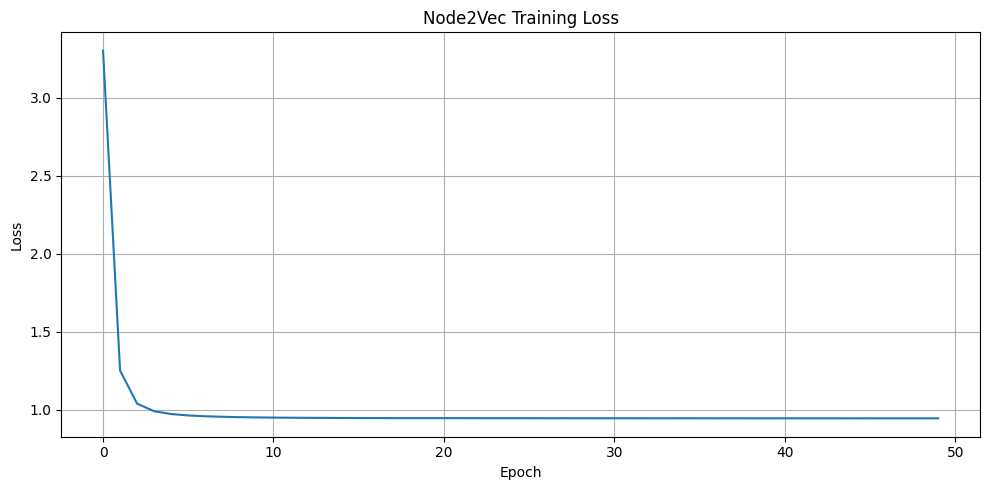

Node2Vec training completed. Final loss: 0.9464
Embeddings shape: torch.Size([13752, 64])


In [16]:
print("Generando embeddings con Node2Vec...")
node_embeddings = train_node2vec(
    data,
    embedding_dim=64,
    walk_length=30,
    num_walks=200,
    p=1,
    q=0.5,
    epochs=50,
    batch_size=128,
    lr=0.01
)

Generando etiquetas para los nodos con tres métodos diferentes...
Generando etiquetas sintéticas usando método: community
Generando etiquetas sintéticas usando método: clustering
Generando etiquetas sintéticas usando método: degree


/usr/local/lib/python3.11/dist-packages/torch_geometric/data/storage.py:452: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


Etiquetas generadas con éxito.
Número de nodos: 13752
Número de aristas: 245861


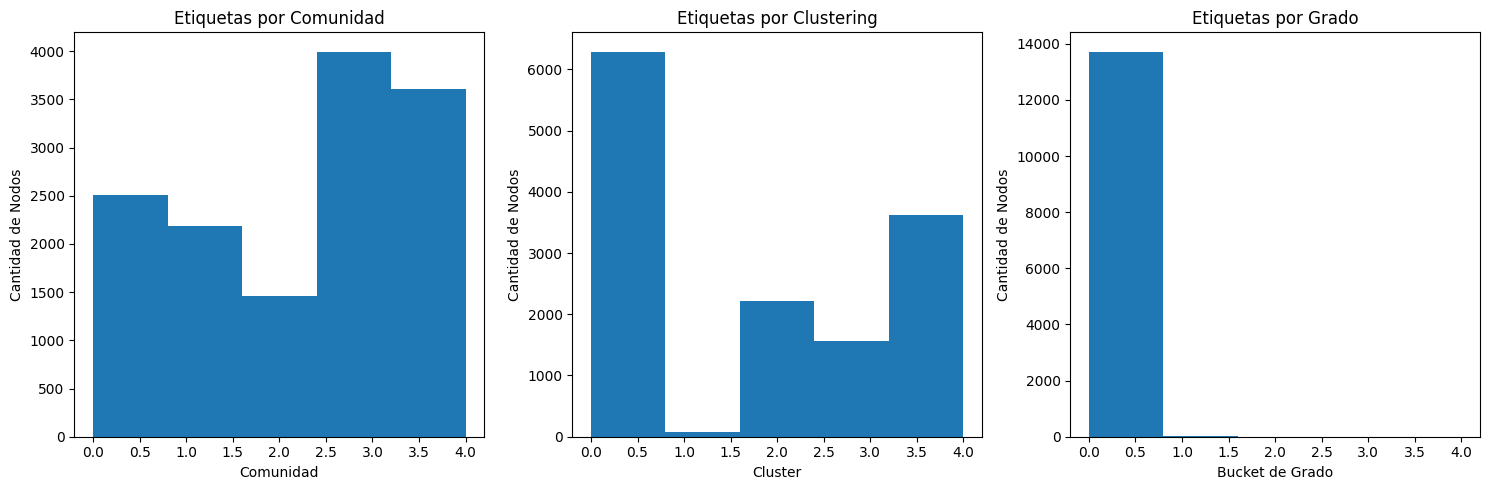

In [17]:
def create_synthetic_node_labels(embeddings=None, edge_index=None, num_nodes=None, method='clustering', n_clusters=5):
    print(f"Generando etiquetas sintéticas usando método: {method}")

    if method == 'clustering' and embeddings is not None:
        embeddings_np = embeddings.detach().cpu().numpy()
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings_np)
        return torch.tensor(labels, dtype=torch.long)

    elif method == 'community' and edge_index is not None:
        temp_data = torch.zeros(num_nodes).reshape(-1, 1)
        temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=edge_index)
        G = to_networkx(temp_data_obj, to_undirected=True)
        partition = community_louvain.best_partition(G)
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, community_id in partition.items():
            labels[node] = community_id % n_clusters

        return labels

    elif method == 'degree' and edge_index is not None:
        G = to_networkx(torch_geometric.data.Data(edge_index=edge_index), to_undirected=True)
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, degree in degrees.items():
            bucket = min(int((degree / max_degree) * n_clusters), n_clusters - 1)
            labels[node] = bucket

        return labels

    else:
        print("Usando método aleatorio para generar etiquetas")
        return torch.randint(0, n_clusters, (num_nodes,))

print("Generando etiquetas para los nodos con tres métodos diferentes...")

community_labels = create_synthetic_node_labels(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    method='community',
    n_clusters=5
)

clustering_labels = create_synthetic_node_labels(
    embeddings=node_embeddings,
    method='clustering',
    n_clusters=5
)

degree_labels = create_synthetic_node_labels(
    edge_index=data.edge_index,
    num_nodes=data.num_nodes,
    method='degree',
    n_clusters=5
)

node_labels = community_labels

print("Etiquetas generadas con éxito.")
print(f"Número de nodos: {data.num_nodes}")
print(f"Número de aristas: {data.edge_index.shape[1] // 2}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(community_labels.numpy(), bins=5)
plt.title('Etiquetas por Comunidad')
plt.xlabel('Comunidad')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 2)
plt.hist(clustering_labels.numpy(), bins=5)
plt.title('Etiquetas por Clustering')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 3)
plt.hist(degree_labels.numpy(), bins=5)
plt.title('Etiquetas por Grado')
plt.xlabel('Bucket de Grado')
plt.ylabel('Cantidad de Nodos')

plt.tight_layout()
plt.show()

# **FILTRADO DE NODOS Y PREPARACIÓN DE DATOS**

In [18]:
def filter_low_degree_nodes(data, node_labels, min_connections=3, negative_samples_ratio=1.0):
    temp_graph = to_networkx(data, to_undirected=True)

    node_degrees = dict(temp_graph.degree())
    nodes_to_keep = [node for node, degree in node_degrees.items() if degree >= min_connections]

    filtered_graph = temp_graph.subgraph(nodes_to_keep)

    print(f"Grafo original: {temp_graph.number_of_nodes()} nodos, {temp_graph.number_of_edges()} aristas")
    print(f"Nodos eliminados: {temp_graph.number_of_nodes() - filtered_graph.number_of_nodes()}")
    print(f"Grafo filtrado: {filtered_graph.number_of_nodes()} nodos, {filtered_graph.number_of_edges()} aristas")

    node_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(filtered_graph.nodes())}

    edge_index = []
    for u, v in filtered_graph.edges():
        edge_index.append([node_mapping[u], node_mapping[v]])
        edge_index.append([node_mapping[v], node_mapping[u]])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t()

    if hasattr(data, 'x') and data.x is not None:
        x = torch.stack([data.x[idx] for idx in nodes_to_keep])
    else:
        x = None

    filtered_labels = torch.stack([node_labels[idx] for idx in nodes_to_keep])
    filtered_data = Data(x=x, edge_index=edge_index)
    filtered_data.num_nodes = filtered_graph.number_of_nodes()

    if negative_samples_ratio > 0:
        num_neg_samples = int(filtered_graph.number_of_edges() * negative_samples_ratio)

        existing_edges = set()
        for u, v in filtered_graph.edges():
            u_mapped = node_mapping[u]
            v_mapped = node_mapping[v]
            existing_edges.add((u_mapped, v_mapped))
            existing_edges.add((v_mapped, u_mapped))

        neg_edge_index = []
        nodes_list = list(range(filtered_data.num_nodes))

        attempts = 0
        max_attempts = num_neg_samples * 10

        while len(neg_edge_index) < num_neg_samples * 2 and attempts < max_attempts:
            u = random.choice(nodes_list)
            v = random.choice(nodes_list)

            if u != v and (u, v) not in existing_edges:
                neg_edge_index.append([u, v])
                neg_edge_index.append([v, u])
                existing_edges.add((u, v))
                existing_edges.add((v, u))

            attempts += 1

        filtered_data.neg_edge_index = torch.tensor(neg_edge_index, dtype=torch.long).t() if neg_edge_index else None
        print(f"Muestras negativas generadas: {len(neg_edge_index) // 2}")

    return filtered_data, filtered_labels, node_mapping

print("Filtrando nodos con menos de 3 conexiones y generando muestras negativas...")
filtered_data, filtered_labels, node_mapping = filter_low_degree_nodes(
    data, node_labels, min_connections=3, negative_samples_ratio=1.0
)

if hasattr(filtered_data, 'neg_edge_index') and filtered_data.neg_edge_index is not None:
    print(f"Número de muestras negativas: {filtered_data.neg_edge_index.shape[1] // 2}")

filtered_data.x = node_embeddings[list(node_mapping.keys())]

num_nodes = filtered_data.num_nodes
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)

filtered_data.train_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)
filtered_data.val_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)
filtered_data.test_mask = torch.zeros(filtered_data.num_nodes, dtype=torch.bool)

filtered_data.train_mask[:train_size] = True
filtered_data.val_mask[train_size:train_size + val_size] = True
filtered_data.test_mask[train_size + val_size:] = True

print(f"Distribución de nodos:")
print(f"  Entrenamiento: {filtered_data.train_mask.sum().item()} nodos")
print(f"  Validación: {filtered_data.val_mask.sum().item()} nodos")
print(f"  Prueba: {filtered_data.test_mask.sum().item()} nodos")


Filtrando nodos con menos de 3 conexiones y generando muestras negativas...
Grafo original: 13752 nodos, 245861 aristas
Nodos eliminados: 941
Grafo filtrado: 12811 nodos, 244949 aristas
Muestras negativas generadas: 244949
Número de muestras negativas: 244949
Distribución de nodos:
  Entrenamiento: 10248 nodos
  Validación: 1281 nodos
  Prueba: 1282 nodos


Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...


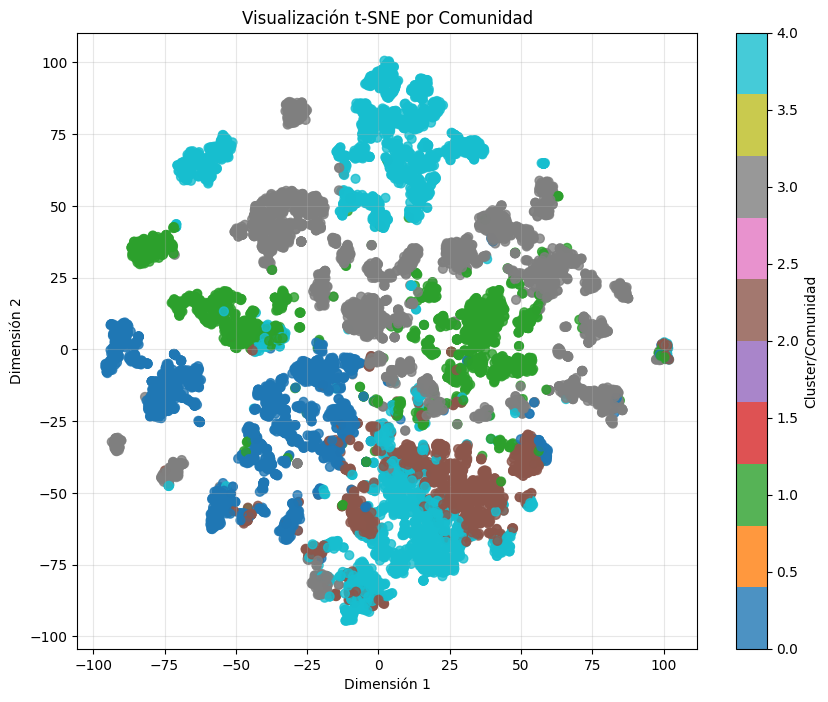

Visualizando grafo con layout spring...


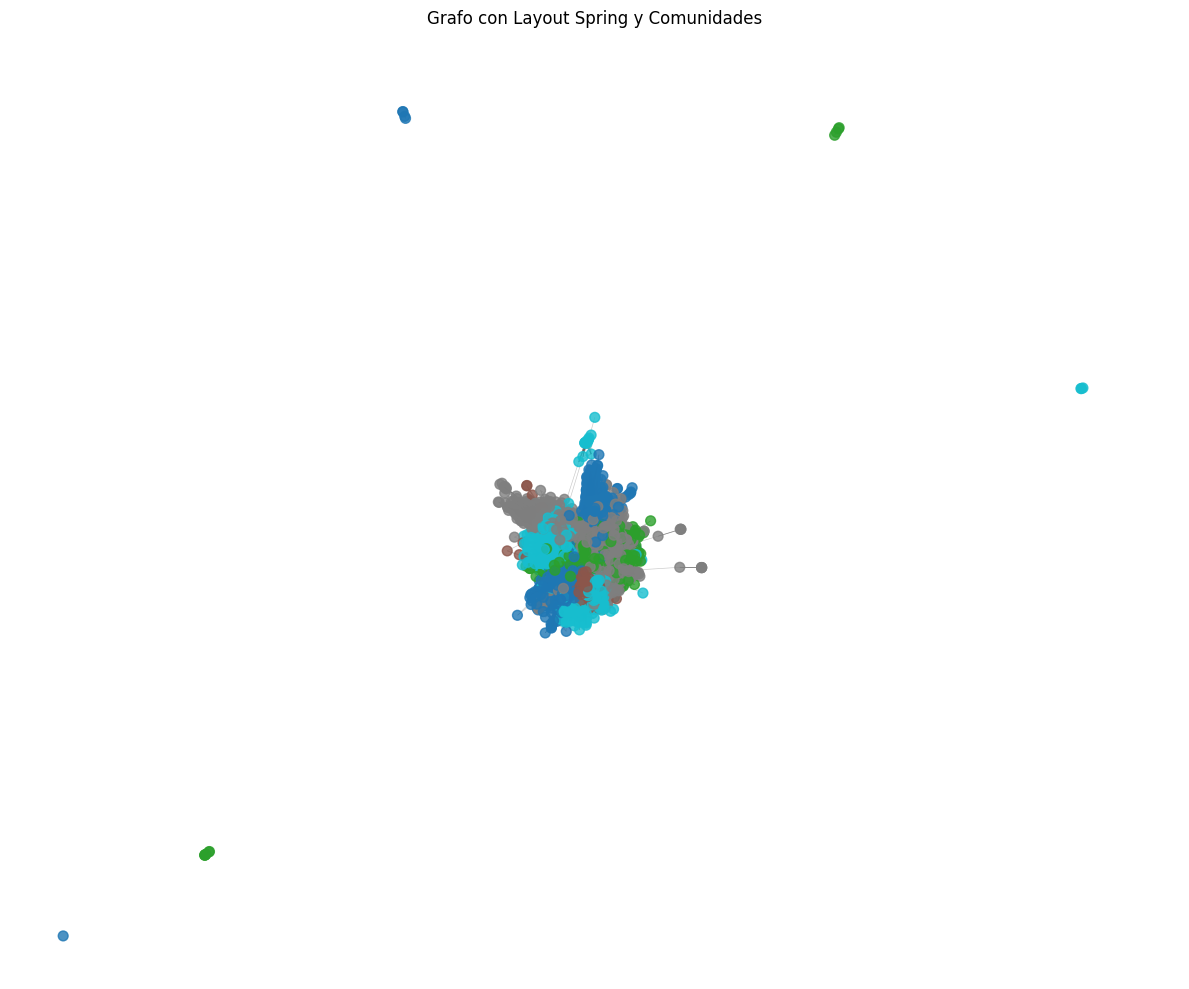

In [19]:
def visualize_embeddings_with_labels(embeddings, labels, title):
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels.cpu().numpy(),
        cmap='tab10',
        alpha=0.8,
        s=40
    )
    plt.colorbar(scatter, label='Cluster/Comunidad')
    plt.title(title)
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')
    plt.grid(alpha=0.3)
    plt.show()

    return embeddings_2d

print("Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...")
embeddings_2d_community = visualize_embeddings_with_labels(
    filtered_data.x,
    filtered_labels,
    'Visualización t-SNE por Comunidad'
)

def visualize_network(data, node_labels=None, layout='spring', title=None):
    print(f"Visualizando grafo con layout {layout}...")

    temp_data = torch.zeros(data.num_nodes).reshape(-1, 1)
    temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=data.edge_index)
    G = to_networkx(temp_data_obj, to_undirected=True)

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 10))

    if node_labels is not None:
        node_colors = node_labels.cpu().numpy()
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                             node_size=50, alpha=0.8, cmap='tab10')
    else:
        nx.draw_networkx_nodes(G, pos, node_size=50, alpha=0.8)

    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

    if title:
        plt.title(title)
    else:
        plt.title(f'Visualización de Grafo con Layout {layout.capitalize()}')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G, pos

G_spring, pos_spring = visualize_network(
    filtered_data,
    node_labels=filtered_labels,
    layout='spring',
    title='Grafo con Layout Spring y Comunidades'
)

# **MODELOS DE CLASIFICACIÓN**

# MLP


Entrenando MLP con los embeddings de Node2Vec...
Entrenando MLP con embeddings de Node2Vec:
  Dimensión de entrada: 64
  Capas ocultas: 128
  Número de clases: 5
  Dropout: 0.5
Época 001: Loss=1.6043, Train=0.5527, Val=0.5472, Test=0.5491
Época 010: Loss=0.6190, Train=0.8737, Val=0.8767, Test=0.8799
Época 020: Loss=0.2129, Train=0.9413, Val=0.9516, Test=0.9446
Época 030: Loss=0.1546, Train=0.9575, Val=0.9586, Test=0.9516
Época 040: Loss=0.1313, Train=0.9649, Val=0.9657, Test=0.9579
Época 050: Loss=0.1192, Train=0.9679, Val=0.9672, Test=0.9626
Época 060: Loss=0.1156, Train=0.9711, Val=0.9688, Test=0.9641
Época 070: Loss=0.1068, Train=0.9710, Val=0.9711, Test=0.9641
Época 080: Loss=0.1062, Train=0.9722, Val=0.9719, Test=0.9641
Época 090: Loss=0.1025, Train=0.9737, Val=0.9719, Test=0.9641
Época 100: Loss=0.1009, Train=0.9748, Val=0.9735, Test=0.9657
Época 110: Loss=0.0992, Train=0.9759, Val=0.9727, Test=0.9649
Época 120: Loss=0.0983, Train=0.9754, Val=0.9719, Test=0.9649
Época 130: Loss=

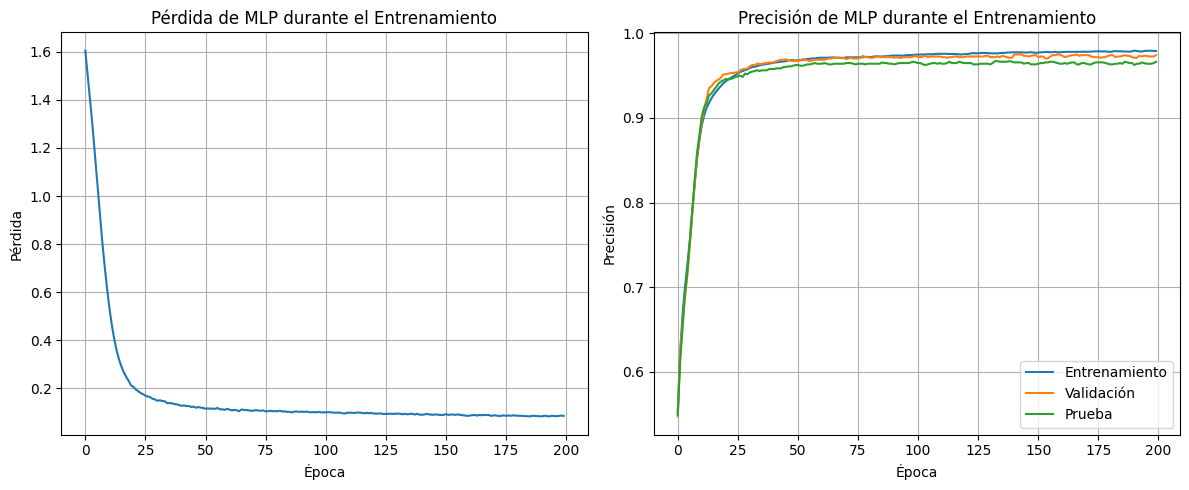

In [20]:
class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(MLP, self).__init__()
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(in_channels, hidden_channels))

        for _ in range(num_layers - 2):
            self.layers.append(torch.nn.Linear(hidden_channels, hidden_channels))

        self.layers.append(torch.nn.Linear(hidden_channels, out_channels))

        self.dropout = dropout

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.layers[-1](x)
        return F.log_softmax(x, dim=1)

def train_evaluate_mlp(node_embeddings, labels, train_mask, val_mask, test_mask,
                       hidden_channels=128, num_layers=2, dropout=0.5,
                       lr=0.01, weight_decay=5e-4, epochs=200, verbose=True):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    node_embeddings = node_embeddings.detach().clone()

    num_nodes = node_embeddings.shape[0]
    in_channels = node_embeddings.shape[1]
    out_channels = int(labels.max()) + 1

    x = node_embeddings.to(device)
    y = labels.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    model = MLP(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_accs, val_accs, test_accs = [], [], []
    losses = []

    best_val_acc = 0
    best_test_acc = 0

    print(f"Entrenando MLP con embeddings de Node2Vec:")
    print(f"  Dimensión de entrada: {in_channels}")
    print(f"  Capas ocultas: {hidden_channels}")
    print(f"  Número de clases: {out_channels}")
    print(f"  Dropout: {dropout}")

    for epoch in range(1, epochs + 1):
        model.train()
        out = model(x)
        loss = F.nll_loss(out[train_mask], y[train_mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x).argmax(dim=1)

            train_correct = pred[train_mask].eq(y[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)

            val_correct = pred[val_mask].eq(y[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)

            test_correct = pred[test_mask].eq(y[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc

        if verbose and (epoch % 10 == 0 or epoch == 1 or epoch == epochs):
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    if verbose:
        print(f"Entrenamiento MLP completado:")
        print(f"  Mejor precisión de validación: {best_val_acc:.4f}")
        print(f"  Precisión de prueba correspondiente: {best_test_acc:.4f}")

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

print("\nEntrenando MLP con los embeddings de Node2Vec...")
filtered_data.x = filtered_data.x.detach().clone()

try:
    mlp_results = train_evaluate_mlp(
        node_embeddings=filtered_data.x,
        labels=filtered_labels,
        train_mask=filtered_data.train_mask,
        val_mask=filtered_data.val_mask,
        test_mask=filtered_data.test_mask,
        hidden_channels=128,
        num_layers=2,
        dropout=0.5,
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        verbose=True
    )
except RuntimeError as e:
    print(f"Error durante el entrenamiento: {e}")
    print("Intentando un enfoque alternativo...")

    x_detached = filtered_data.x.detach().clone()
    labels_detached = filtered_labels.clone()
    train_mask_detached = filtered_data.train_mask.clone()
    val_mask_detached = filtered_data.val_mask.clone()
    test_mask_detached = filtered_data.test_mask.clone()

    mlp_results = train_evaluate_mlp(
        node_embeddings=x_detached,
        labels=labels_detached,
        train_mask=train_mask_detached,
        val_mask=val_mask_detached,
        test_mask=test_mask_detached,
        hidden_channels=128,
        num_layers=2,
        dropout=0.5,
        lr=0.01,
        weight_decay=5e-4,
        epochs=200,
        verbose=True
    )

def plot_mlp_performance(mlp_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(mlp_results['losses'])
    plt.title('Pérdida de MLP durante el Entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(mlp_results['train_accs'], label='Entrenamiento')
    plt.plot(mlp_results['val_accs'], label='Validación')
    plt.plot(mlp_results['test_accs'], label='Prueba')
    plt.title('Precisión de MLP durante el Entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_mlp_performance(mlp_results)

# **GCN**

Arquitectura del modelo GCN:
GCN(
  (convs): ModuleList(
    (0): GCNConv(64, 128)
    (1): GCNConv(128, 5)
  )
)
Número total de parámetros entrenables: 8965
Optimizador inicializado: Adam con lr=0.01, weight_decay=5e-4
Época 000: Loss=1.5964, Train=0.5258, Val=0.5410, Test=0.5211
Época 010: Loss=0.5502, Train=0.9091, Val=0.9180, Test=0.9158
Época 020: Loss=0.2362, Train=0.9376, Val=0.9430, Test=0.9431
Época 030: Loss=0.1590, Train=0.9516, Val=0.9571, Test=0.9509
Época 040: Loss=0.1296, Train=0.9641, Val=0.9664, Test=0.9548
Época 050: Loss=0.1136, Train=0.9687, Val=0.9711, Test=0.9618
Época 060: Loss=0.1060, Train=0.9712, Val=0.9727, Test=0.9626
Época 070: Loss=0.1058, Train=0.9720, Val=0.9750, Test=0.9665
Época 080: Loss=0.1043, Train=0.9725, Val=0.9742, Test=0.9633
Época 090: Loss=0.1004, Train=0.9726, Val=0.9727, Test=0.9688
Época 100: Loss=0.0975, Train=0.9745, Val=0.9750, Test=0.9665
Época 110: Loss=0.0957, Train=0.9745, Val=0.9750, Test=0.9657
Época 120: Loss=0.0955, Train=0.975

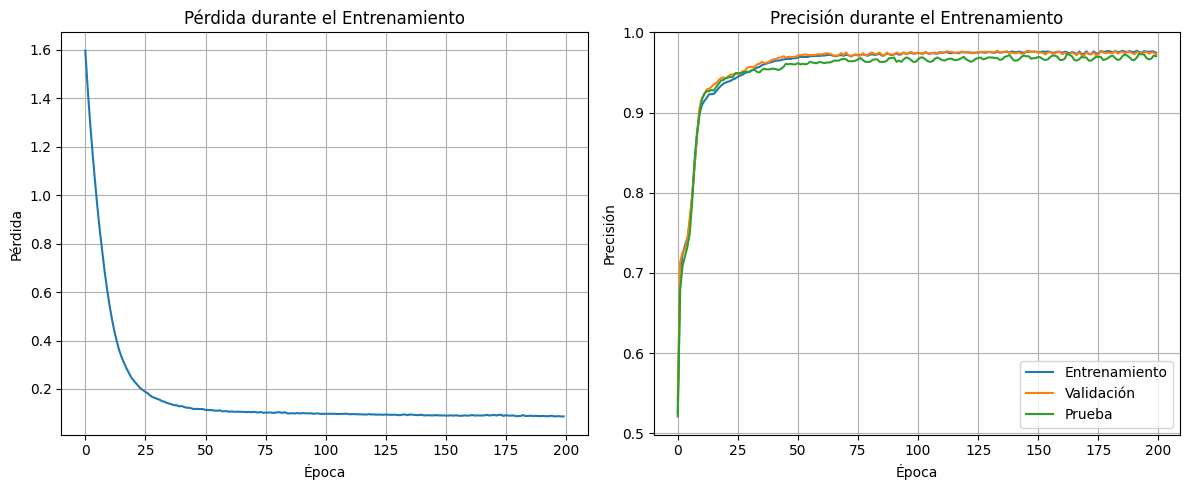

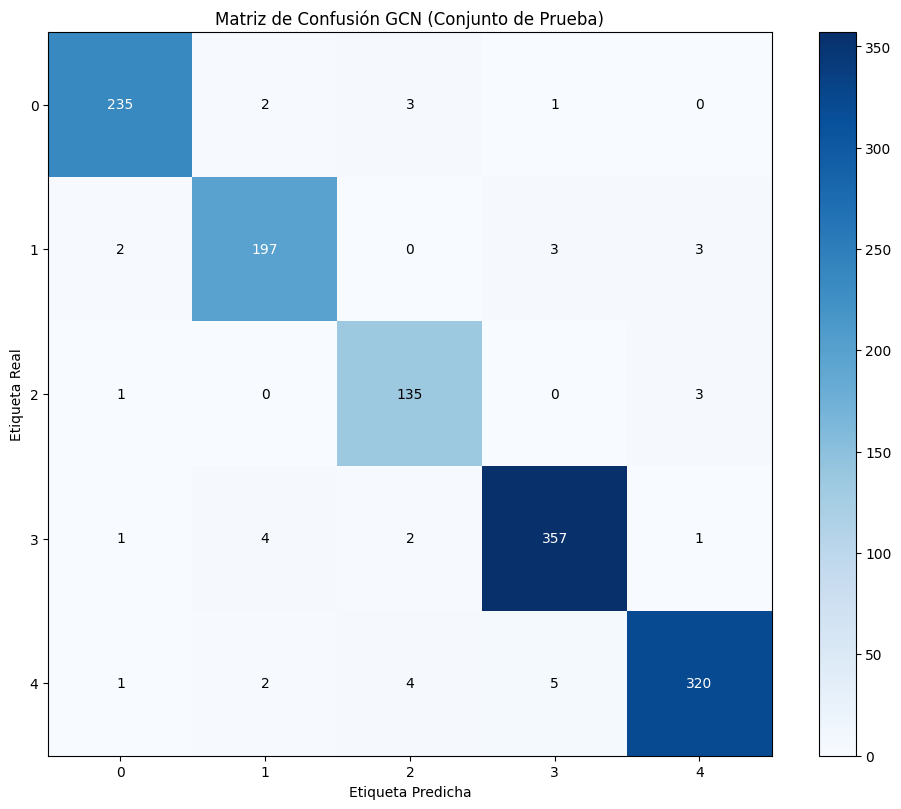

In [24]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(GCN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

gcn_model = GCN(
    in_channels=filtered_data.x.shape[1],
    hidden_channels=128,
    out_channels=5,
    num_layers=2,
    dropout=0.5
)

print("Arquitectura del modelo GCN:")
print(gcn_model)

total_params = sum(p.numel() for p in gcn_model.parameters() if p.requires_grad)
print(f"Número total de parámetros entrenables: {total_params}")

gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
print("Optimizador inicializado: Adam con lr=0.01, weight_decay=5e-4")

def train_evaluate_gnn(model, optimizer, data, node_labels, num_classes=5, epochs=200, verbose=True):
    model = model.to(device)
    x = data.x.to(device)
    edge_index = data.edge_index.to(device)
    labels = node_labels.to(device)
    train_mask = data.train_mask.to(device)
    val_mask = data.val_mask.to(device)
    test_mask = data.test_mask.to(device)
    train_accs, val_accs, test_accs = [], [], []
    losses = []

    best_val_acc = 0
    best_test_acc = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(x, edge_index)
        loss = F.nll_loss(out[train_mask], labels[train_mask])

        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x, edge_index).argmax(dim=1)

            train_correct = pred[train_mask].eq(labels[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)
            val_correct = pred[val_mask].eq(labels[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)
            test_correct = pred[test_mask].eq(labels[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc

        if verbose and epoch % 10 == 0:
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    if verbose:
        print(f"Entrenamiento completado:")
        print(f"  Mejor precisión de validación: {best_val_acc:.4f}")
        print(f"  Precisión de prueba correspondiente: {best_test_acc:.4f}")

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

gcn_results = train_evaluate_gnn(
    gcn_model,
    gcn_optimizer,
    filtered_data,
    filtered_labels,
    num_classes=5,
    epochs=200
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gcn_results['losses'])
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gcn_results['train_accs'], label='Entrenamiento')
plt.plot(gcn_results['val_accs'], label='Validación')
plt.plot(gcn_results['test_accs'], label='Prueba')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

def plot_confusion_matrix(model, data, labels, mask, num_classes=5, title='Matriz de Confusión'):
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device))
        pred = out.argmax(dim=1)

        y_true = labels[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()
        cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

        plt.figure(figsize=(10, 8))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()

        tick_marks = np.arange(num_classes)
        plt.xticks(tick_marks, range(num_classes))
        plt.yticks(tick_marks, range(num_classes))

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, f"{cm[i, j]}",
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2. else "black")

        plt.tight_layout()
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Etiqueta Predicha')

        return plt

test_cm_plot = plot_confusion_matrix(
    gcn_results['model'],
    filtered_data,
    filtered_labels,
    filtered_data.test_mask,
    num_classes=5,
    title='Matriz de Confusión GCN (Conjunto de Prueba)'
)
plt.show()


# **GAT**

Modelo GAT inicializado con:
  Características de entrada: 64
  Capas ocultas: 32 con 8 cabezas de atención
  Salida: 5 clases
Entrenando modelo GAT...
Época 000: Loss=1.6361, Train=0.5625, Val=0.5558, Test=0.5382
Época 010: Loss=0.5331, Train=0.8757, Val=0.8860, Test=0.8752
Época 020: Loss=0.2902, Train=0.9176, Val=0.9266, Test=0.9158
Época 030: Loss=0.2140, Train=0.9415, Val=0.9469, Test=0.9454
Época 040: Loss=0.1822, Train=0.9498, Val=0.9586, Test=0.9509
Época 050: Loss=0.1706, Train=0.9582, Val=0.9594, Test=0.9548
Época 060: Loss=0.1541, Train=0.9634, Val=0.9649, Test=0.9571
Época 070: Loss=0.1424, Train=0.9650, Val=0.9657, Test=0.9571
Época 080: Loss=0.1390, Train=0.9662, Val=0.9680, Test=0.9571
Época 090: Loss=0.1300, Train=0.9677, Val=0.9688, Test=0.9571
Época 100: Loss=0.1285, Train=0.9677, Val=0.9680, Test=0.9594
Época 110: Loss=0.1224, Train=0.9696, Val=0.9711, Test=0.9626
Época 120: Loss=0.1168, Train=0.9701, Val=0.9711, Test=0.9610
Época 130: Loss=0.1171, Train=0.9719, Val=

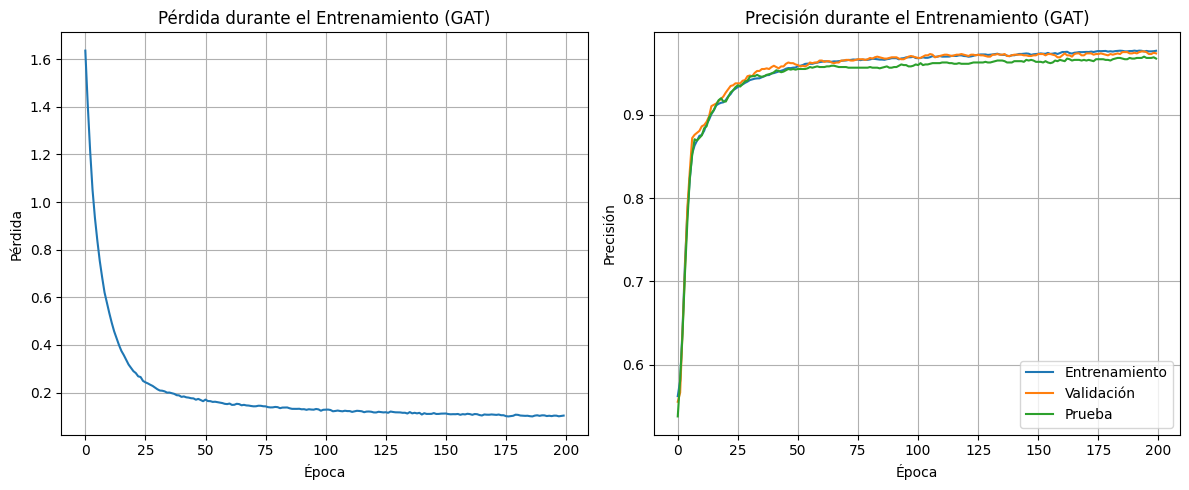

In [22]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=8, dropout=0.6):
        super(GAT, self).__init__()
        self.convs = torch.nn.ModuleList()

        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout))

        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))

        self.convs.append(GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False))

        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

gat_model = GAT(
    in_channels=filtered_data.x.shape[1],
    hidden_channels=32,
    out_channels=5,
    num_layers=2,
    heads=8,
    dropout=0.3
)

gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

print(f"Modelo GAT inicializado con:")
print(f"  Características de entrada: {filtered_data.x.shape[1]}")
print(f"  Capas ocultas: 32 con 8 cabezas de atención")
print(f"  Salida: 5 clases")

print("Entrenando modelo GAT...")
gat_results = train_evaluate_gnn(
    gat_model,
    gat_optimizer,
    filtered_data,
    filtered_labels,
    num_classes=5,
    epochs=200)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gat_results['losses'])
plt.title('Pérdida durante el Entrenamiento (GAT)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gat_results['train_accs'], label='Entrenamiento')
plt.plot(gat_results['val_accs'], label='Validación')
plt.plot(gat_results['test_accs'], label='Prueba')
plt.title('Precisión durante el Entrenamiento (GAT)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **COMPARATIVA DE RENDIMIENTOS**

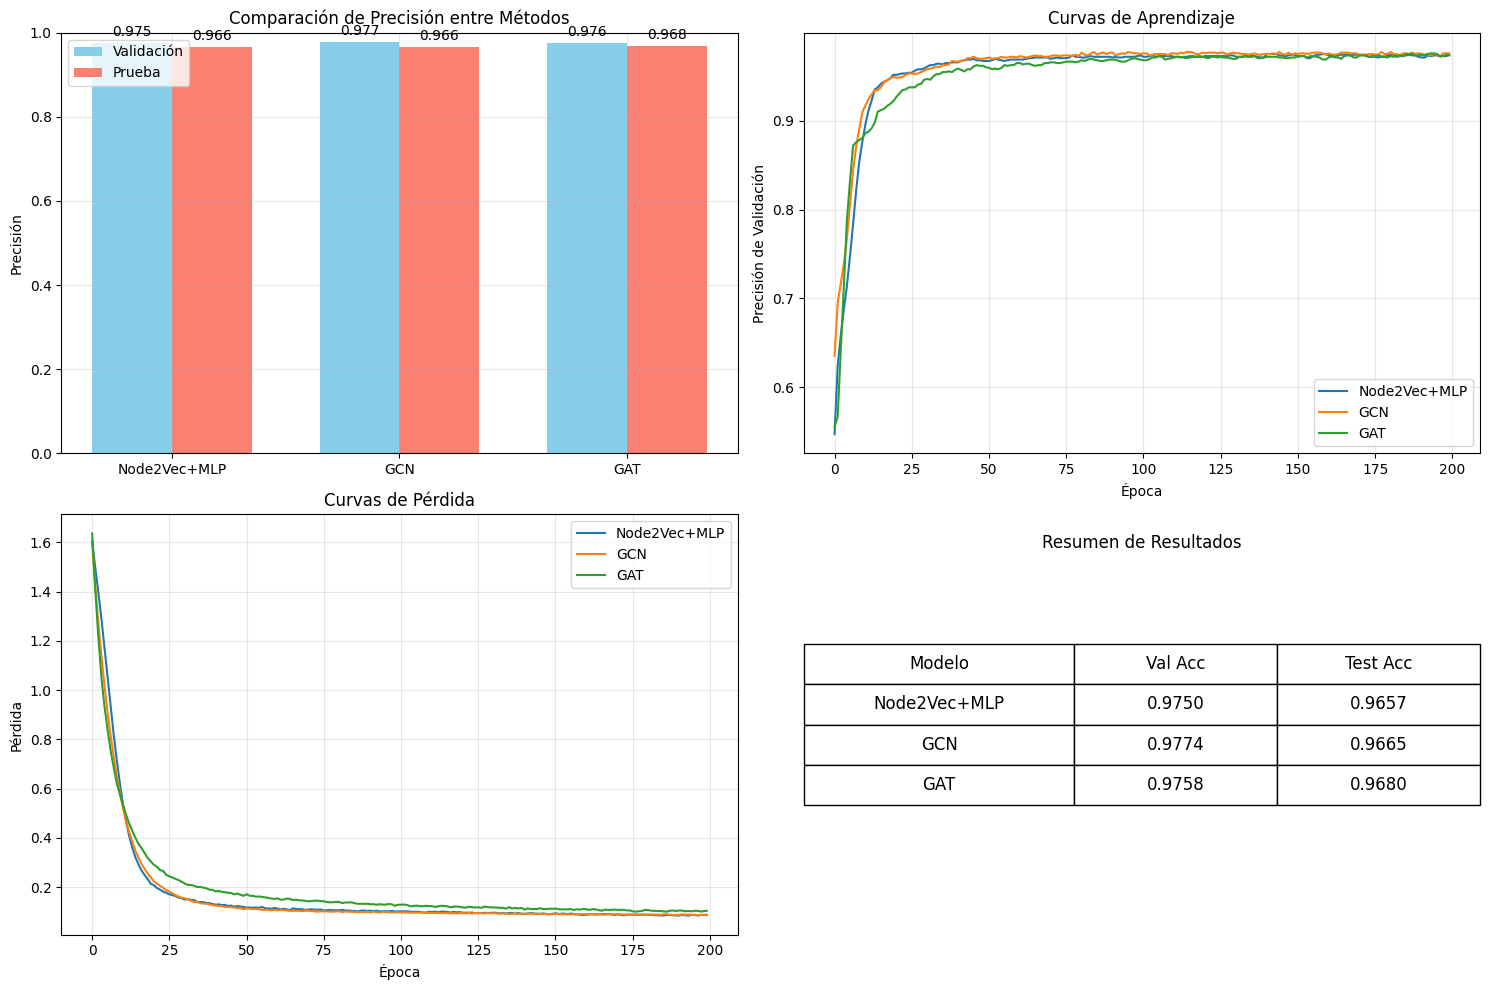

In [23]:
def compare_all_methods(node2vec_mlp_results, gcn_results, gat_results):
    plt.figure(figsize=(15, 10))

    # 1. Comparación de precisión
    plt.subplot(2, 2, 1)
    models = ['Node2Vec+MLP', 'GCN', 'GAT']
    val_accs = [
        node2vec_mlp_results['best_val_acc'],
        gcn_results['best_val_acc'],
        gat_results['best_val_acc']
    ]
    test_accs = [
        node2vec_mlp_results['best_test_acc'],
        gcn_results['best_test_acc'],
        gat_results['best_test_acc']
    ]

    x = range(len(models))
    width = 0.35

    plt.bar([i - width/2 for i in x], val_accs, width, label='Validación', color='skyblue')
    plt.bar([i + width/2 for i in x], test_accs, width, label='Prueba', color='salmon')

    for i, v in enumerate(val_accs):
        plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    for i, v in enumerate(test_accs):
        plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.ylabel('Precisión')
    plt.title('Comparación de Precisión entre Métodos')
    plt.xticks(x, models)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.plot(node2vec_mlp_results['val_accs'], label='Node2Vec+MLP')
    plt.plot(gcn_results['val_accs'], label='GCN')
    plt.plot(gat_results['val_accs'], label='GAT')

    plt.xlabel('Época')
    plt.ylabel('Precisión de Validación')
    plt.title('Curvas de Aprendizaje')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    plt.plot(node2vec_mlp_results['losses'], label='Node2Vec+MLP')
    plt.plot(gcn_results['losses'], label='GCN')
    plt.plot(gat_results['losses'], label='GAT')

    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.title('Curvas de Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.axis('off')
    table_data = [
        ['Modelo', 'Val Acc', 'Test Acc'],
        ['Node2Vec+MLP', f"{node2vec_mlp_results['best_val_acc']:.4f}", f"{node2vec_mlp_results['best_test_acc']:.4f}"],
        ['GCN', f"{gcn_results['best_val_acc']:.4f}", f"{gcn_results['best_test_acc']:.4f}"],
        ['GAT', f"{gat_results['best_val_acc']:.4f}", f"{gat_results['best_test_acc']:.4f}"]
    ]

    table = plt.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.4, 0.3, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    plt.title('Resumen de Resultados', y=0.9)

    plt.tight_layout()
    plt.show()

    models_acc = {
        'Node2Vec+MLP': node2vec_mlp_results['best_test_acc'],
        'GCN': gcn_results['best_test_acc'],
        'GAT': gat_results['best_test_acc']
    }

    best_model = max(models_acc.items(), key=lambda x: x[1])

compare_all_methods(mlp_results, gcn_results, gat_results)